# 17. LangGraph

<br>

## 01. LangGraph의 문법

<br>

### `TypedDict`

<br>

#### `dict`와 `TypedDict`의 차이점
- **타입 검사**
  - `dict` : 런타임에 타입 검사를 하지 않음
  - `TypedDict` : 정적 타입 검사를 제공. 코드 작성 시 IDE나 타입 체커가 오류를 미리 잡아냄
- **키와 값의 타입**
  - `dict` : 키와 값의 타입을 이랍ㄴ적으로 지정
  - `TypedDict` : 각 키에 대한 구체적인 타입을 지정
- **유연성**
  - `dict` : 런타임에 키를 추가하거나 제거
  - `TypedDict` : 정의된 구조를 따라야하며, 추가적인 키는 타입 오류를 발생

<br>

#### `TypedDict` 가 `dict` 대신 사용되는 이유
- **타입 안정성**
  - `TypedDict`는 더 엄격한 타입거사를 제공하며, 잠재적인 버그를 미리 방지할 수 있음
- **코드 가독성**
  - `TypedDict`를 사용하면 딕셔너리의 구조를 명확하게 정의할 수 있어 코드의 가독성이 향상됨
- **IDE 지원**
  - `TypedDict`를 사용하면 IDE에서 자동 완성 및 타입 힌트를 더 정확하게 제공받을 수 있음
- **문서화**
  - `TypedDict`는 코드 자체가 문서의 역할을 하여 딕셔너리의 구조를 명확히 보여줌

<br>

#### 예시

```python
from typing import Dict, TypedDict

# 일반적인 파이썬 딕셔너리(dict) 사용
sample_dict: Dict[str, str] = {
    "name": "테디",
    "age": "30",  # 문자열로 저장 (dict 에서는 가능)
    "job": "개발자",
}


# TypedDict 사용
class Person(TypedDict):
    name: str
    age: int  # 정수형으로 명시
    job: str


typed_dict: Person = {"name": "셜리", "age": 25, "job": "디자이너"}
```

<br>

```python
# dict의 경우
sample_dict["age"] = 35  # 문자열에서 정수로 변경되어도 오류 없음
sample_dict["new_field"] = "추가 정보"  # 새로운 필드 추가 가능

# TypedDict의 경우
typed_dict["age"] = 35  # 정수형으로 올바르게 사용
typed_dict["age"] = "35"  # 타입 체커가 오류를 감지함
typed_dict["new_field"] = (
    "추가 정보"  # 타입 체커가 정의되지 않은 키라고 오류를 발생시킴
)
```

<br>

### `Annotated`
- 타입 힌트에 메타데이터를 추가할 수 있게 해줌

<br>

#### `Annotated` 주요 기능
1. **추가 정보 제공** : 타입 힌트에 메타데이터를 추가하여 더 상세한 정보를 제공
2. **문서화** : 코드 자체에 추가 설명을 포함시켜 문서화 효과를 얻을 수 있음
3. **유효성 검사** : 특정 라이브러리(`Pydantic` 등)와 함께 사용하여 데이터 유효성 검사를 수행할 수 있음
4. **프레임워크 지원** : 일부 프레임워크 (`LangGraph` 등)dptj `Annotated`를 사용하여 동작을 정의

<br>

#### 기본 문법
- `Type` : 기본 타입
- `medadata1`, `metadata2` , ... : 추가하고자하는 메타데이터

```python
from typing import Annotated

variable: Annotated[Type, metadata1, metadata2, ...]
```

<br>

### 사용 예시
- `Pydantic`과 함께 사용

In [5]:
from typing import Annotated, List
from pydantic import Field, BaseModel, ValidationError

In [6]:
class Employee(BaseModel):
    id: Annotated[int, Field(..., description="직원 ID")]
    name: Annotated[str, Field(..., min_length=3, max_length=50, description="이름")]
    age: Annotated[int, Field(gt=18, lt=65, description="나이 (19-64세)")]
    salary: Annotated[
        float, Field(gt=0, lt=10000, description="연봉 (단위: 만원, 최대 10억)")
    ]
    skills: Annotated[
        List[str], Field(min_items=1, max_items=10, description="보유 기술 (1-10개)")
    ]

- 유효한 데이터로 인스턴스 생성

In [7]:
try:
    valid_employee = Employee(
        id=1, name="테디노트", age=30, salary=1000, skills=["Python", "LangChain"]
    )
    print("유효한 직원 데이터:", valid_employee)
except ValidationError as e:
    print("유효성 검사 오류:", e)

유효한 직원 데이터: id=1 name='테디노트' age=30 salary=1000.0 skills=['Python', 'LangChain']


- 유효하지 않은 데이터로 인스턴스 생성 시도

In [8]:
try:
    invalid_employee = Employee(
        name="테디",  # 이름이 너무 짧음
        age=17,  # 나이가 범위를 벗어남
        salary=20000,  # 급여가 범위를 벗어남
        skills="Python",  # 리스트가 아님
    )
except ValidationError as e:
    print("유효성 검사 오류:")
    for error in e.errors():
        print(f"- {error['loc'][0]}: {error['msg']}")


유효성 검사 오류:
- id: Field required
- name: String should have at least 3 characters
- age: Input should be greater than 18
- salary: Input should be less than 10000
- skills: Input should be a valid list


<br>

#### LangGrpah에서의 사용(`add_messages`)
- `add_message`는 LangGraph에서 메시지를 리스트에 추가하는 함수

In [9]:
from typing import Annotated, TypedDict
from langgraph.graph import add_messages

In [10]:
class MyData(TypedDict):
    messages: Annotated[list, add_messages]

<br>

### `add_messages`
- `messages` 키는 `add_messages` 리듀서 함수로 주석이 달려 있으며, 이는 LangGraph에게 기존 목록에 새 메시지를 추가하도록 지시
- 주석이 없는 상태 키는 각 업데이트에 의해 덮여쓰여져 가장 최근의 값이 저장
- `add_messages`함수는 2개의 인자 (`left`, `right`)를 받으며, 좌, 우 메시지를 병합하는 방식으로 동작

<br>

#### 주요 기능
- 두 개의 메시지 리스트를 병합
- 기본적으로 `append-only` 상태를 유지
- 동일한 ID를 가진 메시지가 있을 경우, 새 메시지로 기존 메시지를 대체

<br>

#### 동작 방식
- `right`의 메시지 중 `left`에 동일한 ID를 가진 메시지가 있으면, `right`의 메시지로 대체
- 그 외의 경우 `right`의 메시지가 `left`에 추가

<br>

#### 매개변수
- `left` (Messages) : 기본 메시지 리스트
- `right` (Messages) : 병합할 메시지 리스트 또는 단일 메시지

<br>

#### 반환값
- `Messages` : `right`의 메시지들이 `left`에 병합된 새로운 메시지 리스트

In [11]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import add_messages

In [12]:
msgs1 = [HumanMessage(content="안녕하세요?", id="1")]
msgs2 = [AIMessage(content="반갑습니다~", id="2")]

result1 = add_messages(msgs1, msgs2)
print(result1)

[HumanMessage(content='안녕하세요?', additional_kwargs={}, response_metadata={}, id='1'), AIMessage(content='반갑습니다~', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[])]


<br>

- 동일한 ID를 가진 메시지의 경우

In [13]:
msgs1 = [HumanMessage(content="안녕하세요?", id="1")]
msgs2 = [HumanMessage(content="반갑습니다~", id="1")]

result2 = add_messages(msgs1, msgs2)
print(result2)

[HumanMessage(content='반갑습니다~', additional_kwargs={}, response_metadata={}, id='1')]


<br>

<hr>

<br>

## 02. LangGraph를 활용한 챗봇 구축

In [14]:
from dotenv import load_dotenv

load_dotenv()

True

<br>

### 1. 상태 (State) 정의

In [15]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

- 메시지 정의 : `list type` 이며 `add_messages` 함수를 사용하여 메시지를 추가

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

<br>

### 2. 노드(Node) 정의

- 노드는 작업의 단위를 나타내며, 일반적으로 정규 Python 함수

In [17]:
from langchain_openai import ChatOpenAI

In [18]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

- 챗봇 함수 정의: 현재 State를 입력으로 받아 `"messages"`라는 키 아래에 업데이트된 `messages` 목록을 포함하는 TypedDict을 반환

In [19]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

<br>

### 3. 그래프(Graph) 정의, 노드 추가
- 그래프 생성

In [20]:
graph_builder = StateGraph(State)

- 노드 이름, 함수 혹은 `callable` 객체를 인자로 받아 노드를 추가

In [21]:
graph_builder.add_node("chatbot", chatbot)

<br>

### 4. 그래프 엣지(Edge) 추가
- **`START`는 그래프가 실행될 때마다 작업을 시작할 위치**

In [22]:
graph_builder.add_edge(START, "chatbot")

- **`END`는 그래프 흐름의 종료(끝지점)**

In [23]:
graph_builder.add_edge("chatbot", END)

<br>

### 5. 그래프 컴파일(compile)
- 상태에서 호출할 수 있는 `CompiledGraph`가 생성

In [25]:
graph = graph_builder.compile()

<br>

### 6. 그래프 시각화

In [26]:
from langchain_teddynote.graphs import visualize_graph

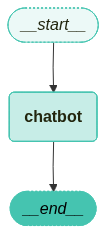

In [27]:
visualize_graph(graph)

<br>

### 7. 그래프 실행

In [28]:
question = "서울의 유명한 맛집 TOP 10 추천해줘"

In [29]:
# 그래프 이벤트 스트리밍
for event in graph.stream({"messages": [("user", question)]}):
    
    # 이벤트 값 출력
    for value in event.values():
        print("Assistant:", value["messages"][-1].content)

Assistant: 서울에는 다양한 맛집이 많아서 선택하기가 쉽지 않지만, 다음은 서울에서 유명한 맛집 TOP 10을 추천해 드립니다.

1. **광장시장** - 전통 시장으로, 빈대떡, 마약김밥, 떡볶이 등 다양한 길거리 음식을 즐길 수 있습니다.

2. **이태원 부대찌개** - 부대찌개로 유명한 이태원의 맛집으로, 푸짐한 양과 깊은 맛이 특징입니다.

3. **명동교자** - 칼국수와 만두로 유명한 맛집으로, 항상 많은 사람들이 줄 서서 기다립니다.

4. **삼청동 수제비** - 수제비와 전통 한식을 즐길 수 있는 곳으로, 아늑한 분위기에서 식사를 할 수 있습니다.

5. **한남동 소고기집** - 고급 소고기를 맛볼 수 있는 곳으로, 품질 좋은 고기를 제공하는 맛집입니다.

6. **홍대 돈부리** - 일본식 덮밥 전문점으로, 다양한 종류의 돈부리를 맛볼 수 있습니다.

7. **강남역 쭈꾸미** - 매콤한 쭈꾸미 요리로 유명한 곳으로, 술안주로도 인기가 많습니다.

8. **부암동 카페** - 맛있는 디저트와 커피를 즐길 수 있는 카페로, 아름다운 경치와 함께 여유로운 시간을 보낼 수 있습니다.

9. **신사동 가로수길** - 다양한 맛집과 카페가 밀집해 있는 지역으로, 트렌디한 음식을 즐길 수 있습니다.

10. **종로 통인시장** - 전통 시장으로, 다양한 한식과 간식을 맛볼 수 있는 곳입니다.

이 외에도 서울에는 많은 맛집이 있으니, 방문하실 때마다 새로운 곳을 탐방해 보세요!


<br>

<hr>

<br>

## 03. LangGraph를 활용한 Agent 구축

<br>

### 도구(Tool) 사용하기

<br>

#### 검색 API 도구 (`TavilySearchResults`)

In [62]:
from langchain_teddynote.tools.tavily import TavilySearch

[{'url': 'https://changsroad.tistory.com/534',
  'title': "한 권으로 끝내는 랭체인 노트 따라하기 Day 0 - Let's be Developers",
  'content': '# 한 권으로 끝내는 랭체인 노트 따라하기 Day 0. 오늘부터 시간날 때마다 `테디노트`님이 작성하신 wikidocs의 랭체인노트 듀토리얼을 보면서 따라해보도록 하겠다! <랭체인LangChain 노트> - LangChain 한국어 튜토리얼🇰🇷. \\*\\*추천\\*\\*은 공유할 수 있는 무료 전자책을 집필하는데 정말 큰 힘이 됩니다. \\*\\*"추천"\\*\\* 한 번씩만 부탁 드리겠습니다🙏🙏 ✅ \\*\\*랭체인 한국어 튜토리얼 강의\\*\\* …. 출처: 테디노트, <랭체인LangChain 노트> - LangChain 한국어 튜토리얼 , CC BY-NC-ND 2.0 KR. #### \'ML & DL > NLP\' 카테고리의 다른 글. | 한 권으로 끝내는 랭체인 노트 따라하기 Day 2 - LCEL\xa0\xa0(0) | 2024.12.23 |. | 한 권으로 끝내는 랭체인 노트 따라하기 Day 1\xa0\xa0(0) | 2024.12.23 |. | [[패캠/NLP] BERT](/455)\xa0\xa0(0) | 2023.12.28 |. | [[패캠/NLP] GPT](/454)\xa0\xa0(0) | 2023.12.27 |. | [[패캠/NLP] Transformer: 트랜스포머](/450)\xa0\xa0(0) | 2023.12.26 |. ## 티스토리툴바.',
  'score': 0.99983,
  'raw_content': 'Let\'s be Developers\n\n![](https://blog.kakaocdn.net/dna/kR3rv/btsLpJ0vV4H/AAAAAAAAAAAAAAAAAAAAAMvZ10BIAA-Tn9CrGdq5bmV39tY1_QIeoUyLDFoUjkUy/img.png?credential=yqXZFxpELC7KV
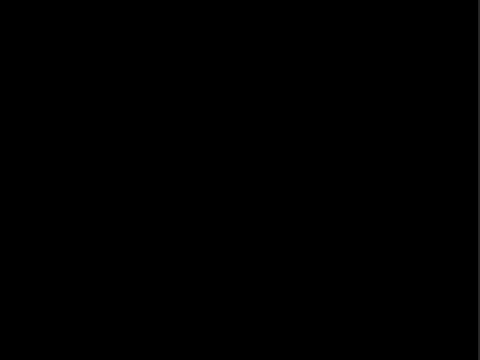

In [63]:
tool = TavilySearch(max_results=3)
tools = [tool]
tool.invoke("테디노트 랭체인 튜토리얼")

<br>

- **LLM에 bind_tools를 추가하여 LLM + 도구 를 구성**

In [113]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

- 상태 (State) 정의

In [114]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

- LLM 을 정의하고 도구를 바인딩

In [115]:
from langchain_openai import ChatOpenAI

In [116]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

- 노드를 정의

In [117]:
def chatbot(state: State):
    answer = llm_with_tools.invoke(state["messages"])
    return {"messages": [answer]}

- 그래프 생성 및 노드를 추가

In [118]:
from langgraph.graph import StateGraph

In [119]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

<br>

### 도구 노드(Tool Node)
- **도구가 호출될 경우 실제로 실행할 수 있는 함수**
  - **가장 최근의 메시지를 확인하고 메시지에 `tool_calls`가 포함되어 있으면 도구를 호출**

In [120]:
import json
from langchain_core.messages import ToolMessage

In [121]:
class BasicToolNode:
    """Run tools requested in the last AIMessage node"""

    def __init__(self, tools: list) -> None:
        # 도구 리스트
        self.tools_list = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        # 메시지가 존재할 경우 가장 최근 메시지 1개 추출
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")

        # 도구 호출 결과
        outputs = []
        for tool_call in message.tool_calls:
            # 도구 호출 후 결과 저장
            tool_result = self.tools_list[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                # 도구 호출 결과를 메시지로 저장
                ToolMessage(
                    content=json.dumps(
                        tool_result, ensure_ascii=False
                    ),  # 도구 호출 결과를 문자열로 변환
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )

        return {"messages": outputs}

- 도구 노드 생성
- 그래프에 도구 노드 추가

In [122]:
tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

<br>

### 조건부 엣지(Conditional Edge)
- 도구 노드가 추가되면 `conditional_edges`를 정의할 수 있음
- Edges는 한 노드에서 다음 노드로 제어 흐름을 라우팅,
  
  **Conditional edges는 일반적으로 `"if"` 문을 포함하여 현재 그래프 상태에 따라 다른 노드로 라우팅**

  $\rightarrow$ **현재 그래프 `state`를 받아 다음에 호출할 Node 를 나타내는 문자열 또는 문자열 목록 을 반환**

<br>

#### `add_conditional_edges`
- `add_conditional_edges` 메서드는 시작 노드에서 여러 대상 노드로의 조건부 엣지를 추가
    
<img src='img/lg17.png' width=400>

<br>

- **매개변수**
  - `source` (str): 시작 노드. 이 노드를 나갈 때 조건부 엣지가 실행
  - `path` (Union[Callable, Runnable]): 다음 노드를 결정하는 호출 가능한 객체 또는 Runnable. 
    - `path_map`을 지정하지 않으면 하나 이상의 노드를 반환
    - `END`를 반환하면 그래프 실행이 중지
  - `path_map` (Optional[Union[dict[Hashable, str], list[str]]]): 경로와 노드 이름 간의 매핑
    - 생략하면 `path`가 반환하는 값이 노드 이름
  - `then` (Optional[str]): path로 선택된 노드 실행 후 실행할 노드의 이름

<br>

- **반환값**
  - `Self`: 메서드 체이닝을 위해 자기 자신을 반환

<br>

- **주요 기능**
    - 조건부 엣지를 그래프에 추가
    - `path_map`을 딕셔너리로 변환
    - path 함수의 반환 타입을 분석하여 자동으로 path_map을 생성할 수 있음
    - 조건부 분기를 그래프에 저장

In [123]:
from langgraph.graph import START, END

In [124]:
def route_tools(
    state: State,
):
    if messages := state.get("messages", []):
        # 가장 최근 AI 메시지 추출
        ai_message = messages[-1]
    else:
        # 입력 상태에 메시지가 없는 경우 예외 발생
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    # AI 메시지에 도구 호출이 있는 경우 "tools" 반환
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        # 도구 호출이 있는 경우 "tools" 반환
        return "tools"
    # 도구 호출이 없는 경우 "END" 반환
    return END

- `tools_condition` 함수는 챗봇이 도구 사용을 요청하면 `"tools"`를 반환하고, 직접 응답이 가능한 경우 `"END"`를 반환

In [126]:
graph_builder.add_conditional_edges(
    source="chatbot",
    path=route_tools,
    # route_tools 의 반환값이 "tools" 인 경우 "tools" 노드로, 그렇지 않으면 END 노드로 라우팅
    path_map={"tools": "tools", END: END},
)

In [127]:
# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

In [128]:
# 그래프 컴파일
graph = graph_builder.compile()

<br>

- **조건부 엣지는 단일 노드에서 시작해야 함**

In [129]:
from langchain_teddynote.graphs import visualize_graph

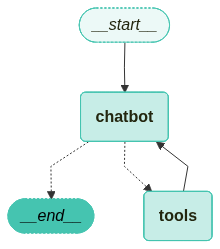

In [130]:
visualize_graph(graph)

<br>

<hr>

<br>

## 04. Agent에 메모리 추가
- **LangGraph는 persistent checkpointing 을 통해 다중 턴 대화를 진행하는 데 제한된 문제를 해결**
  - 그래프를 컴파일할 때 `checkpointer`를 제공하고 그래프를 호출할 때 `thread_id`를 제공하면, LangGraph는 각 단계 후 상태를 자동으로 저장
    
  $\rightarrow$ 동일한 `thread_id`를 사용하여 그래프를 다시 호출하면, 그래프는 저장된 상태를 로드하여 챗봇이 이전에 중단한 지점에서 대화를 이어갈 수 있게 함

- **checkpointing 는 LangChain 의 메모리 기능보다 훨씬 강력**

<br>

- 메모리 저장소 생성

In [131]:
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
memory = MemorySaver()

<br>

#### `in-memory checkpointer`

In [133]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langchain_teddynote.tools.tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

- 상태 정의

In [135]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

- 도구 정의

In [136]:
tool = TavilySearch(max_results=3)
tools = [tool]

- LLM 정의

In [137]:
llm = ChatOpenAI(model="gpt-4o-mini")

- 도구와 LLM 결합

In [138]:
llm_with_tools = llm.bind_tools(tools)

- 챗봇 함수 정의

In [139]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

- 상태 그래프 생성

In [141]:
graph_builder = StateGraph(State)

- 챗봇 노드 추가

In [142]:
graph_builder.add_node("chatbot", chatbot)

- 도구 노드 생성 및 추가


In [143]:
tool_node = ToolNode(tools=[tool])

- 도구 노드 추가


In [144]:
graph_builder.add_node("tools", tool_node)

- 조건부 엣지

In [145]:
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

* 엣지 추가

In [146]:
# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

<br>

- **`checkpointer`를 사용하여 그래프를 컴파일**

In [147]:
graph = graph_builder.compile(checkpointer=memory)

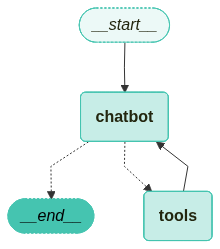

In [148]:
visualize_graph(graph)

<br>

### `RunnablConfig` 설정
- `RunnableConfig` 을 정의하고 `recursion_limit` 과 `thread_id` 를 설정
  - `recursion_limit`: 최대 방문할 노드 수. 그 이상은 `RecursionError` 발생
  - `thread_id`: 스레드 ID 설정
    - **`thread_id` 는 대화 세션을 구분하는 데 사용 $\rightarrow$ 즉, 메모리의 저장은 `thread_id` 에 따라 개별적으로 실행**

In [149]:
from langchain_core.runnables import RunnableConfig

In [151]:
config = RunnableConfig(
    recursion_limit=10,  # 최대 10개의 노드까지 방문. 그 이상은 RecursionError 발생
    configurable={"thread_id": "1"},  # 스레드 ID 설정
)

In [ ]:
question = (
    "내 이름은 `테디노트` 입니다. YouTube 채널을 운영하고 있어요. 만나서 반가워요"
)

for event in graph.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

안녕하세요, 테디노트님! 만나서 반갑습니다. YouTube 채널을 운영하고 계시다니 정말 멋지네요! 어떤 주제로 채널을 운영하고 계신가요? 도움이 필요하시면 언제든지 말씀해 주세요.


In [154]:
question = "내 이름이 뭐라고 했지?"

for event in graph.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

귀하의 이름은 "테디노트"입니다.


<br>

- **`thread_id` 를 변경**

In [156]:
question = "내 이름이 뭐라고 했지?"

config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": "2"},
)

for event in graph.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()


================================== Ai Message ==================================

죄송하지만, 저는 당신의 이름을 알지 못합니다. 대화 기록이 없기 때문입니다. 필요하신 다른 정보나 질문이 있으시면 말씀해 주세요!


<br>

### 스냅샷: 저장된 State 확인
- `Checkpoint` 에는 현재 상태 값, 해당 구성, 그리고 처리할 next 노드가 포함
- **주어진 설정에서 그래프의 `state`를 검사하려면 `get_state(config)`를 호출**

In [157]:
from langchain_core.runnables import RunnableConfig

In [158]:
config = RunnableConfig(
    configurable={"thread_id": "1"},  # 스레드 ID 설정
)

In [159]:
snapshot = graph.get_state(config)
snapshot.values["messages"]

[HumanMessage(content='내 이름은 `테디노트` 입니다. YouTube 채널을 운영하고 있어요. 만나서 반가워요', additional_kwargs={}, response_metadata={}, id='e56fa9b7-dace-4095-8905-50ce001f04a2'),
 AIMessage(content='안녕하세요, 테디노트님! 만나서 반갑습니다. YouTube 채널을 운영하고 계시다니 정말 멋지네요! 어떤 주제로 채널을 운영하고 계신가요? 도움이 필요하시면 언제든지 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 118, 'total_tokens': 175, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4d98e63255', 'id': 'chatcmpl-DIV7qyMiY2yPPHYSeeqo2CJlBFOIP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ce107-f700-72f3-ad2c-1129739df716-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 118, 'output_tokens

- `config` 정보를 확인

In [160]:
snapshot.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11de86-66d8-6f23-8004-958bf4da7ada'}}

-  지금까지 저장된 `state` 값

In [164]:
(snapshot.values)

{'messages': [HumanMessage(content='내 이름은 `테디노트` 입니다. YouTube 채널을 운영하고 있어요. 만나서 반가워요', additional_kwargs={}, response_metadata={}, id='e56fa9b7-dace-4095-8905-50ce001f04a2'),
  AIMessage(content='안녕하세요, 테디노트님! 만나서 반갑습니다. YouTube 채널을 운영하고 계시다니 정말 멋지네요! 어떤 주제로 채널을 운영하고 계신가요? 도움이 필요하시면 언제든지 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 118, 'total_tokens': 175, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4d98e63255', 'id': 'chatcmpl-DIV7qyMiY2yPPHYSeeqo2CJlBFOIP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ce107-f700-72f3-ad2c-1129739df716-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 118, 

- 앞으로 찾아갈 다음 노드를 확인

In [165]:
snapshot.next

()

In [170]:
snapshot.metadata

{'source': 'loop', 'step': 4, 'parents': {}}

<br>

<hr>